# Librerías

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

# Funcion de preprocesamiento

In [1]:
def preprocess_ct_scan(scan_path,hu_min=-1000,hu_max=400):
    scan = sitk.ReadImage(scan_path)

    volume_original = sitk.GetArrayFromImage(
        scan
    ).astype(np.float32)

    volume_preprocessed = np.clip(
        volume_original,
        hu_min,
        hu_max
    )

    volume_preprocessed = (
        volume_preprocessed - hu_min
    ) / (hu_max - hu_min)

    return volume_original, volume_preprocessed

# Cargar una tomografía

In [4]:
scan_path = (
    "data/subset8/"
    "1.3.6.1.4.1.14519.5.2.1.6279.6001."
    "100225287222365663678666836860.mhd"
)

original, processed = preprocess_ct_scan(
    scan_path
)

# Mostrar un Slice

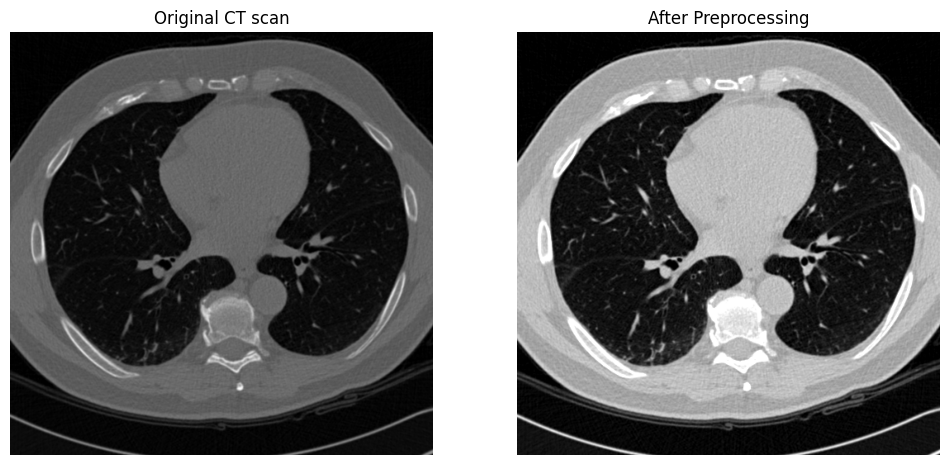

In [8]:
slice_id = original.shape[0] // 2

fig, ax = plt.subplots(1,2,figsize=(12,6))

ax[0].imshow(original[slice_id],cmap="gray")
ax[0].set_title("Original CT scan")
ax[0].axis("off")

ax[1].imshow(processed[slice_id],cmap="gray")

ax[1].set_title("After Preprocessing")
ax[1].axis("off")

plt.show()

# Comparar histogramas

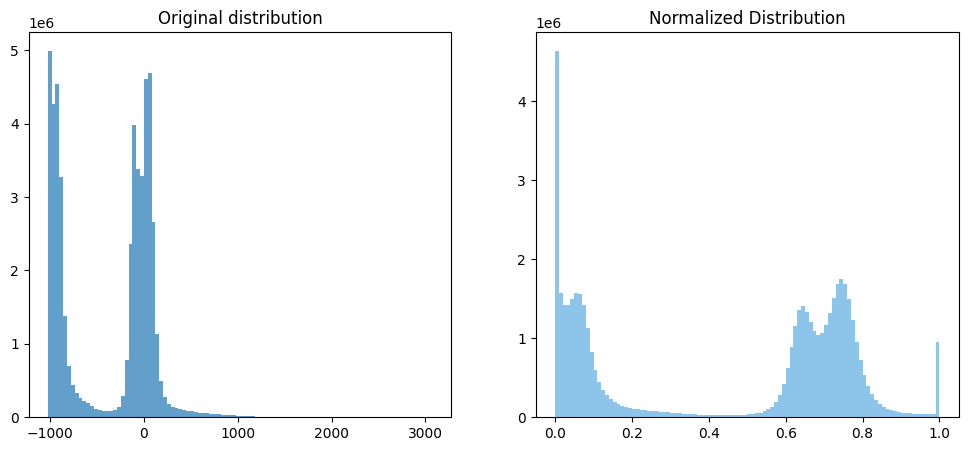

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(original.flatten(), bins=100, color='#1f77b4', alpha=0.7)
ax[0].set_title("Original distribution")

ax[1].hist(processed.flatten(), bins=100, color='#5DADE2', alpha=0.7)
ax[1].set_title("Normalized Distribution")

plt.show()

# Verificar rangos

In [7]:
print("Tomografía original")

print(f"HU mínimo : {original.min():.1f}")
print(f"HU máximo : {original.max():.1f}")

print("\nTomografía preprocesada")

print(f"Mínimo : {processed.min():.3f}")
print(f"Máximo : {processed.max():.3f}")

Tomografía original
HU mínimo : -1024.0
HU máximo : 3071.0

Tomografía preprocesada
Mínimo : 0.000
Máximo : 1.000
